# Tech Challenge: Classificando a qualidade de vinhos com Machine Learning

Este notebook atende ao desafio de prever a qualidade de
um vinho com base em suas características físico-químicas.
- Quality >= 7: Vinho de alta qualidade.
- Quality < 7: Vinho de baixa/média qualidade.

## 1. Compreensão do Problema

- Variável alvo original: quality
- Transformação binária: quality_binary = 1 se quality >= 7, senão 0
- Objetivo: Treinar e avaliar modelos de aprendizado de máquina capazes de prever essa classificação a partir das variáveis disponíveis.

### Ferramentas e imports principais

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    )

In [20]:
# Configura estilo dos gráficos para melhorar legibilidade.
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

# Localiza a raiz do projeto tanto ao abrir pela raiz quanto pela pasta notebooks/.
project_root = Path.cwd().resolve()
if not (project_root / 'data' / 'winequality-red.csv').exists():
    project_root = project_root.parent

data_path = project_root / 'data' / 'winequality-red.csv'
results_dir = project_root / 'results'
results_dir.mkdir(parents=True, exist_ok=True)

if not data_path.exists():
    raise FileNotFoundError(f'Dataset não encontrado em: {data_path}')

### Leitura do dataset de vinhos

In [21]:
# Leitura do dataset de vinhos.
df = pd.read_csv(data_path)

# Transforma a qualidade original em alvo binário:
# 1 = alta qualidade (quality >= 7), 0 = baixa/media (quality < 7).
df['quality_binary'] = (df['quality'] >= 7).astype(int)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,quality_binary
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4,0


In [22]:
#Números representando  a dimensionalidade do conjunto de dados
df.shape

(1143, 14)

## 2. Análise Exploratória de Dados (EDA)



Dimensão da base (linhas, colunas): (1143, 14)

Quantidade de valores nulos por coluna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
quality_binary          0
dtype: int64


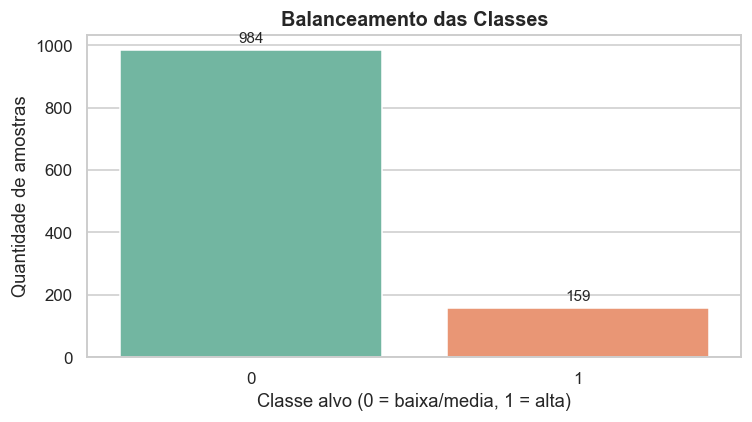


Interpretação do gráfico:
- Classe 0 (baixa/media): 86.1%
- Classe 1 (alta): 13.9%
- Quanto mais desbalanceadas as barras, maior o cuidado na avaliação dos modelos.


In [23]:
# Visão geral da base.
print('Dimensão da base (linhas, colunas):', df.shape)
print('\nQuantidade de valores nulos por coluna:')
print(df.isnull().sum())

# Gráfico 1: balanceamento das classes.
# Ele mostra quantos vinhos há em cada classe do alvo binário.
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x='quality_binary', hue='quality_binary', palette='Set2', legend=False)
ax.set_title('Balanceamento das Classes', fontsize=13, weight='bold')
ax.set_xlabel('Classe alvo (0 = baixa/media, 1 = alta)')
ax.set_ylabel('Quantidade de amostras')

# Adiciona os valores no topo de cada barra para leitura imediata.
for p in ax.patches:
    altura = int(p.get_height())
    ax.annotate(
        f'{altura}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        xytext=(0, 3),
        textcoords='offset points'
    )

plt.tight_layout()
plt.savefig(results_dir / 'balanceamento_classes.png', dpi=300, bbox_inches='tight')
plt.show()

proporcao = df['quality_binary'].value_counts(normalize=True).sort_index()
print('\nInterpretação do gráfico:')
print(f"- Classe 0 (baixa/media): {proporcao.loc[0]*100:.1f}%")
print(f"- Classe 1 (alta): {proporcao.loc[1]*100:.1f}%")
print('- Quanto mais desbalanceadas as barras, maior o cuidado na avaliação dos modelos.')

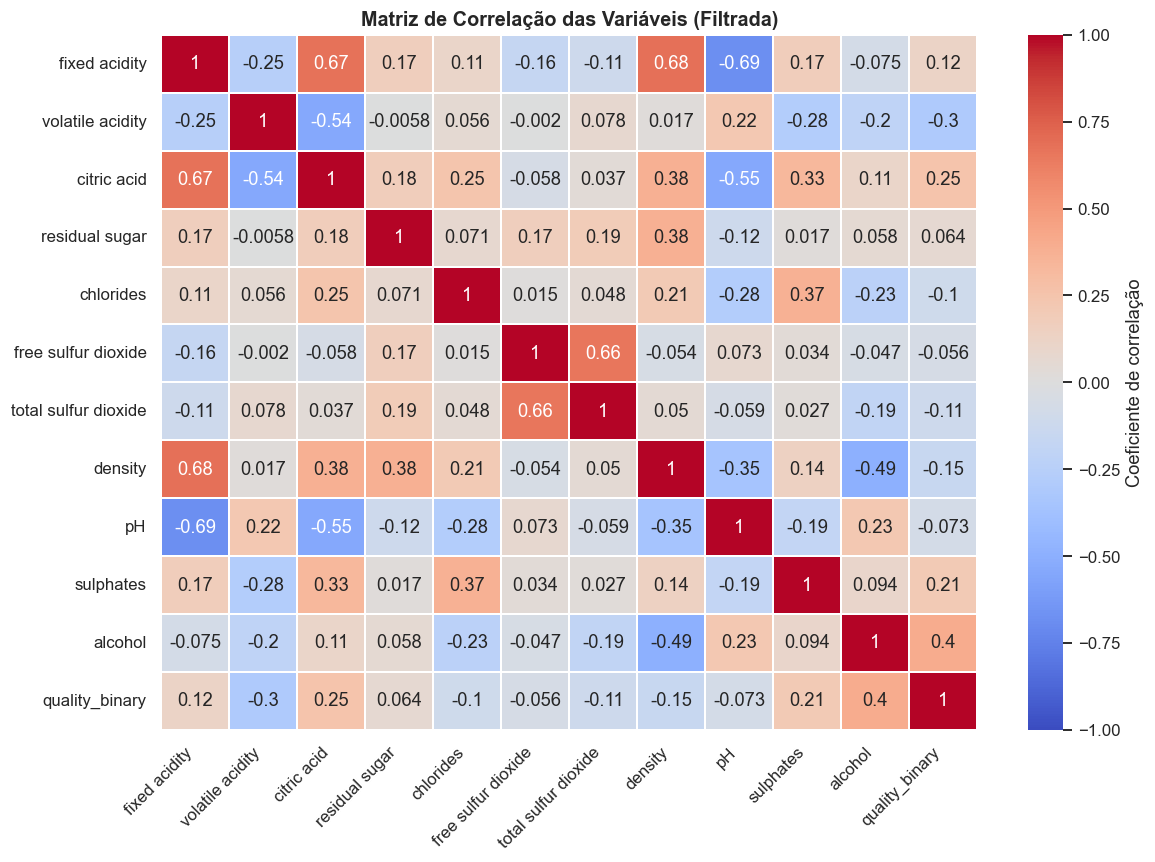

Interpretação do gráfico (top 5 correlações reais com qualidade_binary):
- alcohol: correlação positiva (0.404)
- volatile acidity: correlação negativa (-0.305)
- citric acid: correlação positiva (0.251)
- sulphates: correlação positiva (0.208)
- density: correlação negativa (-0.149)

Leitura rápida: valores mais próximos de +1 ou -1 indicam relação mais forte com a classe alvo.


In [56]:
# Gráfico 2: mapa de calor de correlações entre variáveis numéricas.
# Cores próximas de vermelho = correlação positiva forte.
# Cores próximas de azul = correlação negativa forte.

# Excluímos 'Id' e 'quality' para evitar redundâncias automáticas, pouco informativas e vazamento de dados (data leakage)
df_filtrado = df.drop(columns=['Id', 'quality'], errors='ignore')
corr = df_filtrado.corr(numeric_only=True)

plt.figure(figsize=(11, 8))
ax = sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    linewidths=0.3,
    cbar_kws={'label': 'Coeficiente de correlação'}
)
ax.set_title('Matriz de Correlação das Variáveis (Filtrada)', fontsize=13, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(results_dir / 'matriz_correlacao.png', dpi=300, bbox_inches='tight')
plt.show()

# Mostra automaticamente as correlações mais fortes com o alvo para facilitar interpretação.
corr_alvo = corr['quality_binary'].drop('quality_binary').sort_values(key=np.abs, ascending=False)
print('Interpretação do gráfico (top 5 correlações reais com qualidade_binary):')
for nome, valor in corr_alvo.head(5).items():
    direcao = 'positiva' if valor >= 0 else 'negativa'
    print(f'- {nome}: correlação {direcao} ({valor:.3f})')

print('\nLeitura rápida: valores mais próximos de +1 ou -1 indicam relação mais forte com a classe alvo.')

### Distribuição das variáveis (histogramas)

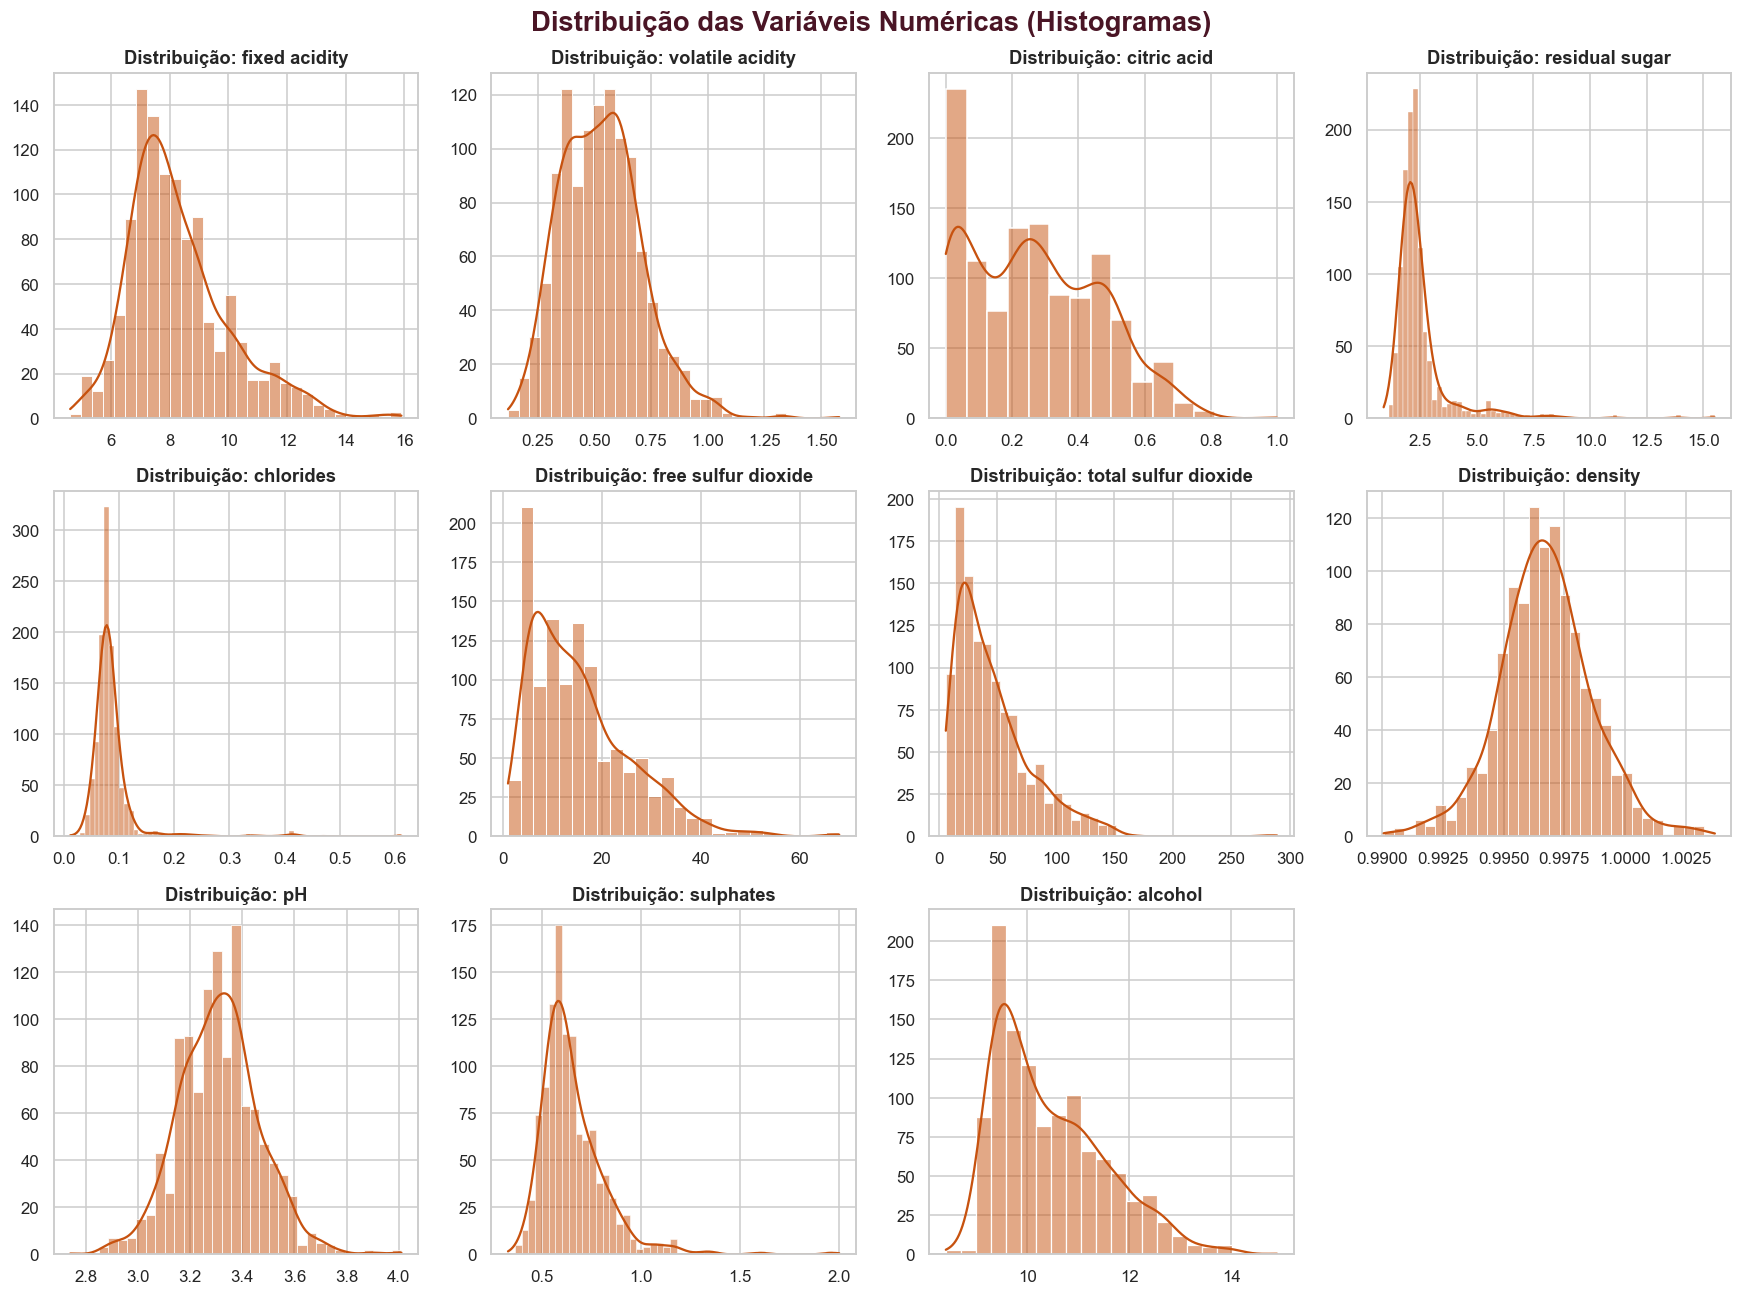

In [25]:
# Garantindo que a lista de variáveis esteja na memória da célula
variaveis_preditoras = [
    "fixed acidity", "volatile acidity", "citric acid", "residual sugar","chlorides", "free sulfur dioxide", 
    "total sulfur dioxide","density", "pH", "sulphates", "alcohol"
]

# Garantindo que o 'X' seja recriado do df
X = df[variaveis_preditoras].copy() 

# Configurando os Histogramas
plt.figure(figsize=(16, 12)) # Tamanho da figura ajustado para melhor visualização dos histogramas
plt.suptitle("Distribuição das Variáveis Numéricas (Histogramas)", # Título do gráfico principal
              fontsize=18, 
              weight='bold', 
              color='#4a1525') 

for i, col in enumerate(variaveis_preditoras, 1): # Enumerate permite iterar sobre a lista de variáveis, fornecendo um índice (i) e o nome da coluna (col)
    plt.subplot(3, 4, i)
    sns.histplot(data=X, x=col, kde=True, color="#c7520f") 
    plt.title(f'Distribuição: {col}', fontsize=12, weight='semibold')
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout() # Ajusta o layout para evitar sobreposição de elementos
plt.savefig(results_dir / 'distribuicao_histogramas.png', dpi=300, bbox_inches='tight') # Salva o gráfico como imagem
plt.show() # Plota os histogramas

### Insights da análise exploratória (EDA)

Após a análise visual das distribuições e dispersões das características químicas dos vinhos, foram consolidados os seguintes apontamentos:

* **Assimetria nas distribuições (Histogramas):** Variáveis como `residual sugar` (açúcar residual) e `chlorides` (cloretos) apresentam uma distribuição altamente concentrada à esquerda com caudas longas à direita. Isso indica que a grande maioria dos vinhos da base possui características secas e baixa salinidade, com poucos lotes fora do padrão.
* **Presença crítica de outliers (boxplots):** Praticamente todas as variáveis numéricas apresentam pontos isolados além das cercas do boxplot, com destaque extremo para `residual sugar` e `chlorides`. Esses valores discrepantes são candidatos naturais para tratamento ou uso de modelos baseados em árvores, que são menos sensíveis a essas distorções.
* **Proximidade com a normalidade:** A variável `pH` e a variável `density` (densidade) são as únicas que se aproximam visualmente de uma curva Gaussiana perfeita (distribuição normal), indicando um controle padrão rígido de acidez global no processo de fabricação desses vinhos.

### Identificação de outliers (boxplots)

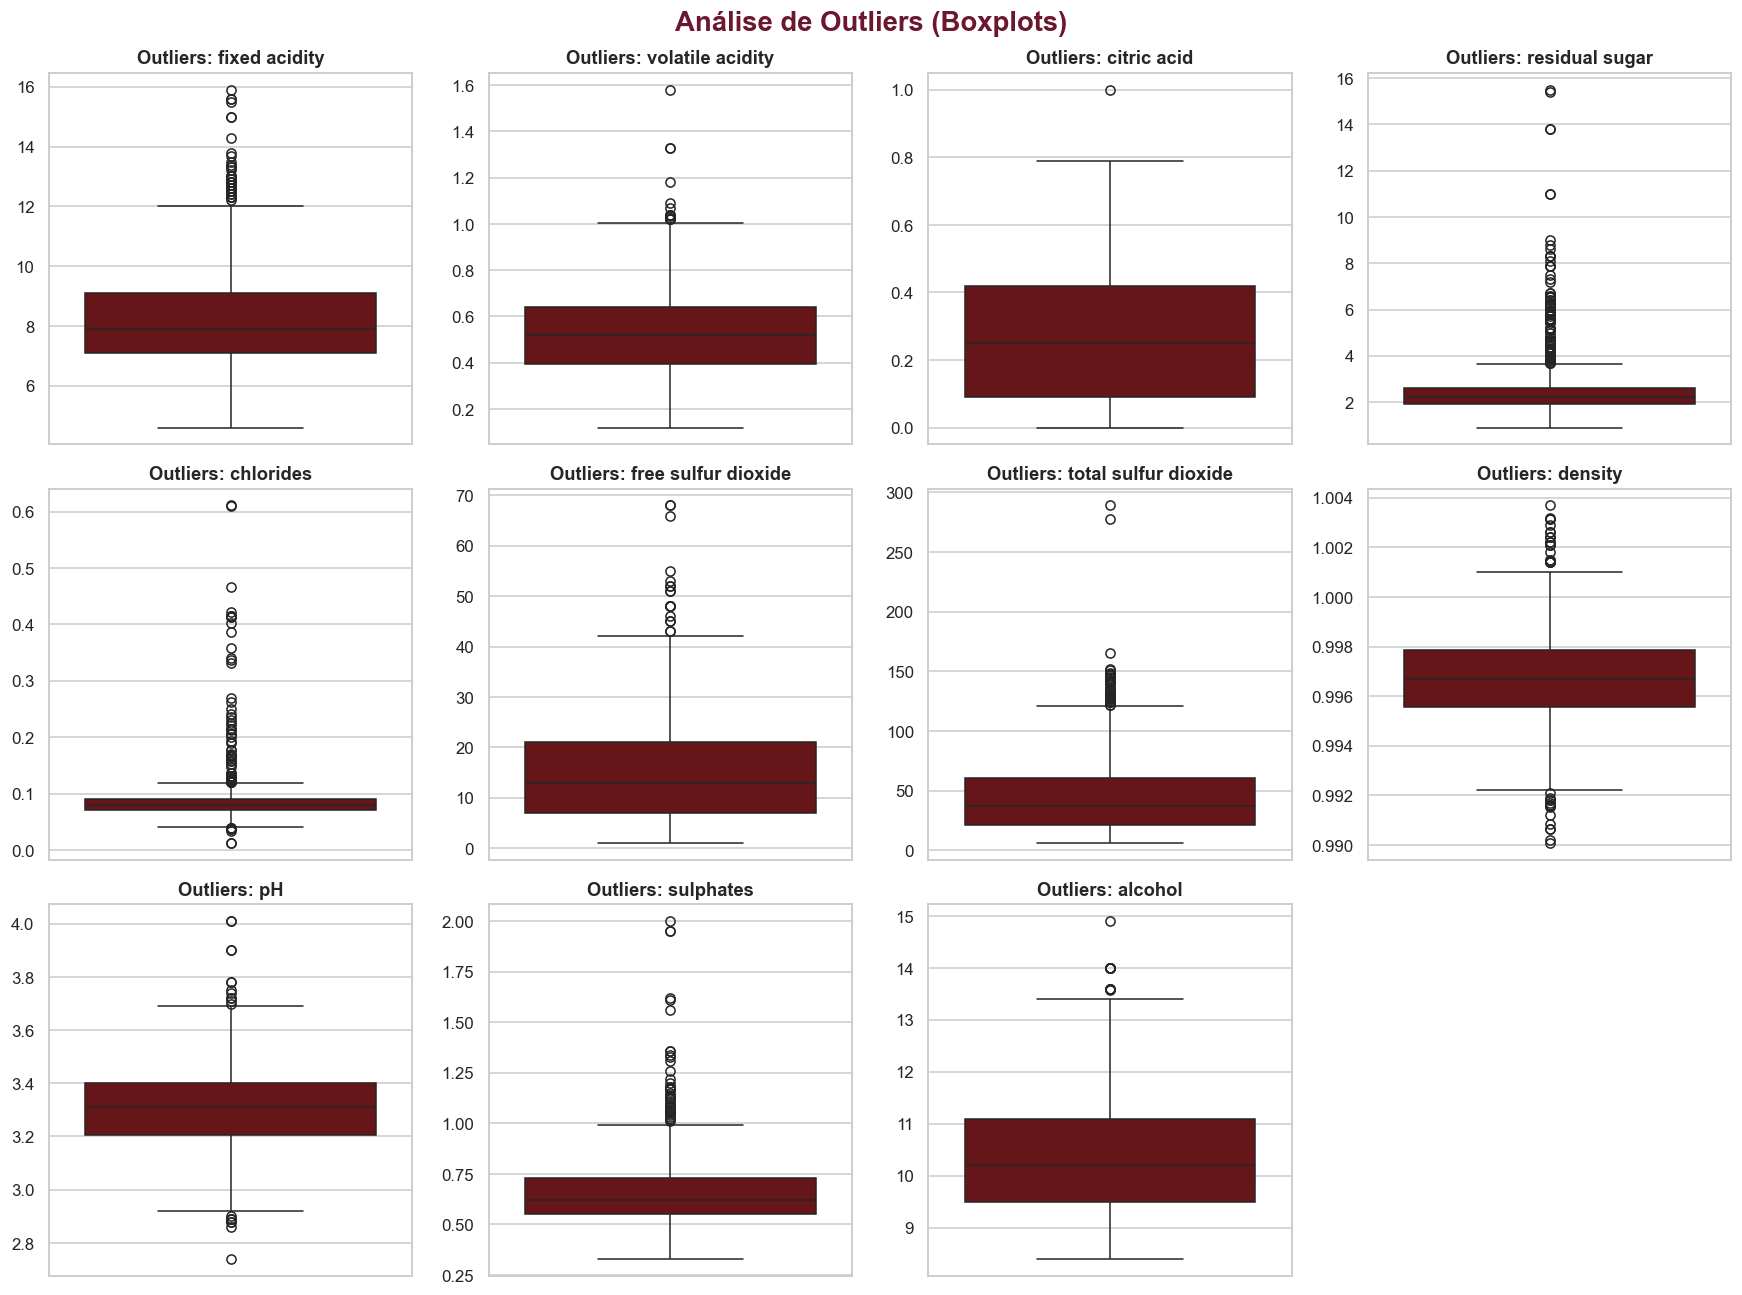

In [26]:
# 2. Boxplots para Identificação de Outliers
plt.figure(figsize=(16, 12))
plt.suptitle("Análise de Outliers (Boxplots)", fontsize=18, weight='bold', color="#6b1730")

# Criando o grid de boxplots para as variáveis do modelo
for i, col in enumerate(variaveis_preditoras, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(data=X, y=col, color="#74070d")
    plt.title(f'Outliers: {col}', fontsize=12, weight='semibold')
    plt.ylabel('')

plt.tight_layout()
plt.savefig(results_dir / 'analise_outliers_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Preparação dos Dados para Machine Learning

Nesta etapa, a base será preparada para o treinamento dos modelos de classificação. 
A variável `quality_binary` será utilizada como alvo, onde:

- 1 representa vinho de alta qualidade (`quality >= 7`);
- 0 representa vinho de baixa/média qualidade (`quality < 7`).

A coluna `quality` será removida das variáveis de entrada para evitar vazamento de informação, pois ela foi usada para criar a variável alvo binária.

In [27]:
# Visualizando o DataFrame atual
display(df.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,quality_binary
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4,0


In [28]:
# Conferência das colunas
print("Colunas da base:")
print(df.columns.tolist())

Colunas da base:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id', 'quality_binary']


In [29]:
# Coletando as variáveis preditoras (independentes): características físicas-químicas do vinho.
variaveis_preditoras = [
    "fixed acidity","volatile acidity","citric acid","residual sugar",
    "chlorides","free sulfur dioxide","total sulfur dioxide",
    "density","pH","sulphates", "alcohol",
]

In [30]:
# Variável X contém as variáveis preditoras/independentes
X = df[variaveis_preditoras].copy()

# Variável que os modelos tentarão prever:
# Y é o target (dependente): 1 = alta qualidade e 0 = baixa/média qualidade.
y = df["quality_binary"].copy()

print("\nColunas usadas no modelo:")
print(X.columns.tolist())

print("\nDistribuição da variável alvo:")
print(y.value_counts())

print("\nProporção da variável alvo:")
print(y.value_counts(normalize=True))


Colunas usadas no modelo:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Distribuição da variável alvo:
quality_binary
0    984
1    159
Name: count, dtype: int64

Proporção da variável alvo:
quality_binary
0    0.860892
1    0.139108
Name: proportion, dtype: float64


## 4. Separação entre Treino e Teste

A base será dividida entre treino e teste. 
Como existe desbalanceamento entre as classes, será utilizado o parâmetro `stratify=Y` para preservar a proporção de vinhos de alta qualidade e baixa/média qualidade nas duas amostras.

| Objeto    | Descrição                                     |
| --------- | -------------------------------------------------- |
| `X_train` | Dados usados para o modelo aprender                |
| `Y_train` | Respostas usadas no treinamento                    |
| `X_test`  | Dados usados para testar o modelo                  |
| `Y_test`  | Respostas verdadeiras para comparar com a previsão |


In [31]:
# Dividindo os dados entre treino e teste
# Separando os dados entre treino e teste 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 5. Treinamento dos Modelos

Nesta etapa, serão treinados quatro modelos de classificação para comparar qual deles consegue prever melhor se um vinho é de **alta qualidade** ou de **baixa/média qualidade**.

Os modelos escolhidos foram:

1. **Regressão Logística**  
   Esse modelo foi escolhido por ser uma opção mais simples e fácil de entender.  
   Ele trabalha com a ideia de probabilidade, ou seja, tenta calcular a chance de um vinho pertencer a uma das classes, como por exemplo: qual a probabilidade desse vinho ser de alta qualidade?

2. **Árvore de Decisão**  
   Esse modelo ajuda a criar regras de decisão com base nas características dos vinhos.  
   Ele funciona como uma sequência de perguntas, por exemplo: o teor alcoólico é maior que determinado valor? A acidez está abaixo de certo limite?  
   Isso ajuda bastante na interpretação, porque conseguimos entender melhor quais condições influenciam a classificação.

3. **Random Forest**  
   O Random Forest é parecido com a Árvore de Decisão, mas em vez de usar apenas uma árvore, ele usa várias árvores ao mesmo tempo.  
   Cada árvore faz uma previsão, e no final o modelo combina essas respostas para chegar a uma classificação final.  
   Por isso, ele pode ser mais estável e menos dependente de uma única regra.

4. **SVM com RBF**  
   Esse modelo foi incluído para testar uma forma diferente de separar as classes.  
   Enquanto alguns modelos trabalham de forma mais direta, o SVM com RBF tenta encontrar uma separação mais flexível entre os vinhos de alta qualidade e os demais.  
   Isso pode ajudar quando a diferença entre as classes depende da combinação de várias características ao mesmo tempo.

A ideia de usar esses quatro modelos é comparar abordagens diferentes: uma simples, uma baseada em regras, uma que combina várias árvores e outra que tenta separar as classes de forma mais flexível.

## Modelo: Regressão logistica

In [32]:
# Definindo a estrutura do pipeline, ajustnado hiperparâmetros básicos da Regressão logistica
lr_pipeline = Pipeline([                            # Tupla que recebe lista de tarefas a serem executadas sequencialmente
    ('imputer', SimpleImputer(strategy='median')),  # Substitui valores ausentes pela mediana da coluna
    ('scaler', StandardScaler()),                   # Padroniza os dados para média 0 e desvio padrão 1
    ('model', LogisticRegression(class_weight='balanced', # Ajusta o peso das classes para lidar com desbalanceamento
                                 C=1.0,             # Controla a regularização como "freio" (quanto maior, menos regularização)
                                 random_state=42))  # Semente aleatória para os cálculos se repetirem, garantindo reprodutibilidade dos resultados
])

### Treino

In [33]:
# Treinando a nossa esteira completa com os dados de treino
# Método fit ajusta/treina o modelo com os dados de treino, aplicando as transformações definidas no pipeline.
# X_train é a tabela com as variáveis preditoras de treino (tipo caderno de questões)
# y_train é a variável alvo de treino (o gabarito com as respostas)
lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

### Gerando as previsões 

In [34]:
# Gerando palpites finais (0 ou 1) para o conjunto de teste
y_pred = lr_pipeline.predict(X_test) # Este método trás o resultado final

# Gerando as probabilidades de o vinho ser de alta qualidade (Classe 1)
y_proba = lr_pipeline.predict_proba(X_test)[:, 1] # Este método devolve o nível de certeza do modelo trazendo a segunda coluna (1)
                                                  # que é a métrica ROC pra avaliar a probabilidade da classe positiva (alta qualidade). 
                                                  # A primeira coluna (0) é a probabilidade da classe negativa (baixa/média qualidade).

### Avaliação de Métricas

In [35]:
# Métricas de análises individuais
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")  # Taxa de acertos do modelo
print(f"Precisão: {precision_score(y_test, y_pred):.4f}") # Proporção de previsões corretas entre as amostras classificadas como positivas
print(f"Recall:   {recall_score(y_test, y_pred):.4f}")    # Proporção de amostras positivas corretamente identificadas pelo modelo
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")        # Média entre precisão e recall
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")   # Área sob a curva ROC, quanto mais perto do 1.0, mais o modelo distingui que o vinho é bom do que comum

Acurácia: 0.7991
Precisão: 0.3793
Recall:   0.6875
F1-Score: 0.4889
ROC-AUC: 0.8504


### Matriz de confusão

In [36]:
# Matriz de confusão e o relatório resumido
print("\n=== MATRIZ DE CONFUSÃO ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== RELATÓRIO DE CLASSIFICAÇÃO ===")
print(classification_report(y_test, y_pred))


=== MATRIZ DE CONFUSÃO ===
[[161  36]
 [ 10  22]]

=== RELATÓRIO DE CLASSIFICAÇÃO ===
              precision    recall  f1-score   support

           0       0.94      0.82      0.88       197
           1       0.38      0.69      0.49        32

    accuracy                           0.80       229
   macro avg       0.66      0.75      0.68       229
weighted avg       0.86      0.80      0.82       229



### Plotando as informações do modelo

/Users/danna.bigois/.pyenv/versions/3.13.13/lib/python3.13/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


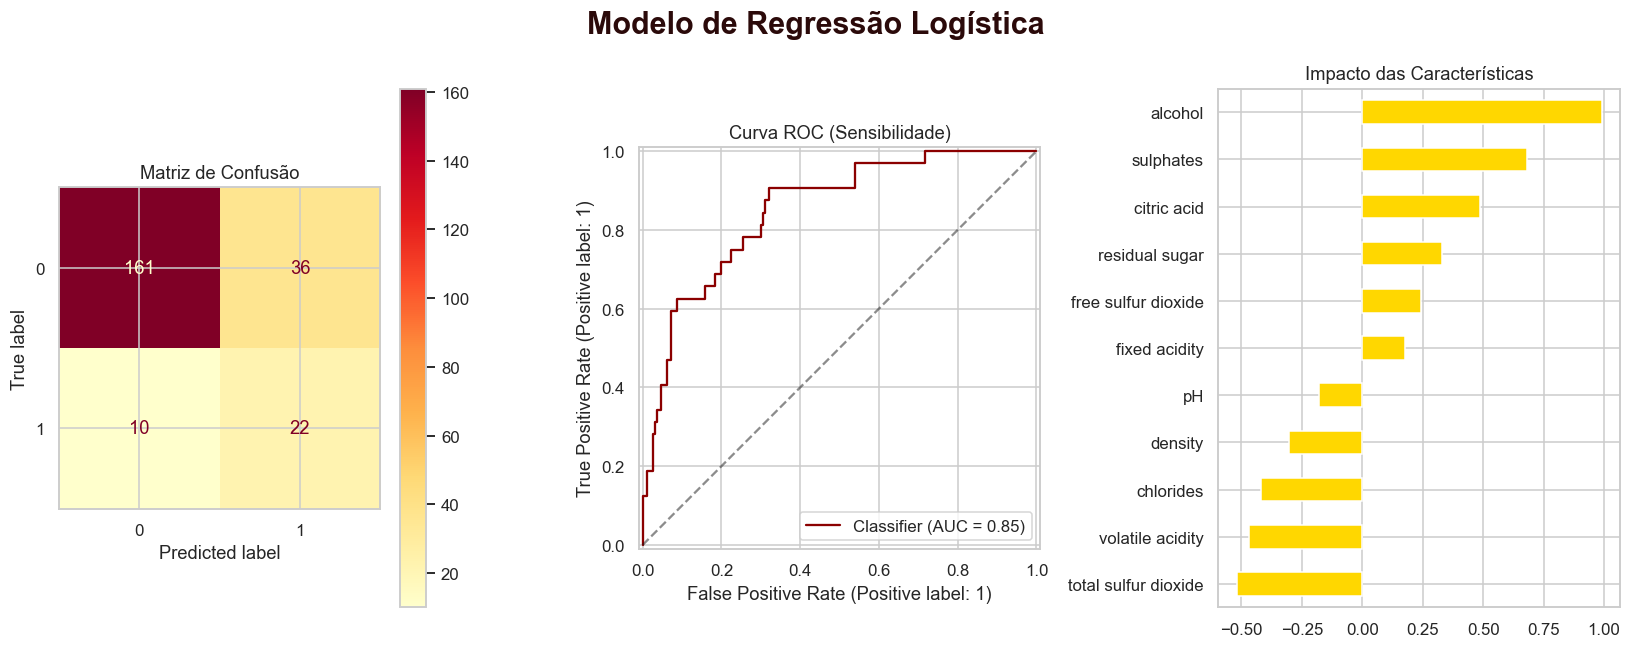

In [37]:
# Configurando o tema visual e o tamanho do painel
sns.set_theme(style="whitegrid") # Configura o estilo visual dos gráficos
plt.rcParams['figure.figsize'] = (15, 6) # Define o tamanho padrão dos gráficos para 15 polegadas de largura e 6 polegadas de altura

# Criando o esqueleto com 3 sub-gráficos lado a lado
fig, (ax1, ax2, ax3) = plt.subplots(1, 3) # Cria uma figura com 3 subplots lado a lado

# Adicionando título principal do modelo
plt.suptitle("Modelo de Regressão Logística", fontsize=20, weight='bold', color='#2b0a0a') # Adiciona título principal do modelo com fonte maior, negrito e cor personalizada

# Plotando a Matriz de Confusão no primeiro eixo
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax1, cmap='YlOrRd') # Plota a matriz de confusão usando as previsões do modelo e o conjunto de teste
ax1.set_title("Matriz de Confusão") # Titulo do gráfico da matriz de confusão

# Plotando a Curva ROC no segundo eixo
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax2, color='darkred') # Plota a curva ROC usando as probabilidades previstas pelo modelo e o conjunto de teste
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax2.set_title("Curva ROC (Sensibilidade)") # Titulo do gráfico da curva ROC

# Extraindo e plotando os coeficientes (impacto) no terceiro eixo
coefs = lr_pipeline.named_steps['model'].coef_[0] # Acessa os coeficientes do modelo de regressão logística treinado, que indicam a importância de cada variável preditora na decisão do modelo
features = X_train.columns                        # Acessa os nomes das colunas do conjunto de treino, que correspondem às variáveis preditoras usadas no modelo
importancia = pd.Series(coefs, index=features).sort_values() # Cria uma série pandas com os coeficientes do modelo, indexada pelos nomes das variáveis preditoras ordenadas
importancia.plot(kind='barh', ax=ax3, color='gold') # Plota um gráfico de barras horizontal mostrando a importância de cada característica na decisão do modelo
ax3.set_title("Impacto das Características") # Titulo do gráfico do impacto das características

# Ajustando o espaçamento entre os gráficos
plt.tight_layout()

# Salvando o gráfico automaticamente na pasta de resultados
plt.savefig(results_dir / 'regressao_logistica_outputs.png', dpi=300, bbox_inches='tight')

# Plotando o gráfico
plt.show()

### Análise de Desempenho: Regressão Logística

O modelo apresentou uma base estatística sólida, mas revelou um desafio prático de negócio (um *trade-off*) que precisa ser considerado na tomada de decisão.

---

### Pontos fortes
* **Robustez Estatística:** O modelo é robusto, ostentando um **ROC-AUC de 0.85** e uma **Acurácia Geral de 80%**. Esses indicadores validam a nossa hipótese inicial de que as variáveis físico-químicas — como o teor alcoólico e os níveis de acidez — estão diretamente conectadas à percepção de qualidade do vinho.
* **Sensibilidade à classe minoritária:** O uso de pesos balanceados funcionou para erguer o **Recall para 68,75%** (o nosso *detetive de plantão*). Esse ajuste foi crucial para impedir que os vinhos premium (classe minoritária) fossem ignorados pelo algoritmo durante o aprendizado.

### Gargalo (Ponto Crítico)
* **Baixa precisão (37,93%):** Por estar muito focado em capturar todos os vinhos excelentes, o modelo tornou-se excessivamente **"permissivo"**. Isso gerou um gargalo operacional: um volume alto de alarmes falsos, onde **36 vinhos comuns** foram erroneamente classificados como sendo de alta qualidade.

---

### Conclusão e próximos passos
> Este modelo de Regressão Logística servirá oficialmente como o nosso **modelo de baseline** (nossa linha de base). Para as próximas etapas do projeto, precisaremos de modelos preditivos mais complexos capazes de mapear relações não-lineares, buscando **reduzir os 36 alarmes falsos** (melhorando a Precisão) sem perder a capacidade atual de identificar os bons vinhos (preservando o Recall).

## Modelo: Árvore de decisão

In [38]:
# Montando a esteira Pipeline e ajustando os hiperparâmetros da árvore
dt_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Substitui valores ausentes pela mediana da coluna
    ('model', DecisionTreeClassifier(class_weight='balanced', # Ajusta o peso das classes para lidar com desbalanceamento
                                     max_depth=5,  # Limita a profundidade máxima da árvore para evitar overfitting (memorização excessiva dos dados de treino)
                                     random_state=42)) # Semente aleatória para os cálculos se repetirem, garantindo reprodutibilidade dos resultados
])

### Treino

In [39]:
# Treinando o Pipeline da Árvore de Decisão com os dados de treino
dt_pipeline.fit(X_train, y_train) # O método fit ajusta/treina o modelo com os dados de treino, aplicando as transformações definidas no pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a fe

### Gerando previsões

In [40]:
# Gerando os palpites finais (0 ou 1) com a Árvore de Decisão
y_pred = dt_pipeline.predict(X_test) # Este método trás o resultado final

# Gerando as probabilidades de o vinho ser de alta qualidade (Classe 1)
y_proba = dt_pipeline.predict_proba(X_test)[:, 1] # Este método devolve o nível de certeza do modelo trazendo a segunda coluna (1)

### Avaliação das métricas

In [41]:
# Métricas de análises individuais para a árvore de decisão
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")  # Taxa de acertos do modelo
print(f"Precisão: {precision_score(y_test, y_pred):.4f}") # Proporção de previsões corretas entre as amostras classificadas como positivas
print(f"Recall:   {recall_score(y_test, y_pred):.4f}")    # Proporção de amostras positivas corretamente identificadas pelo modelo
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")        # Média entre precisão e recall
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")   # Área sob a curva ROC, quanto mais perto do 1.0, mais o modelo distingui que o vinho é bom do que comum

Acurácia: 0.8035
Precisão: 0.3968
Recall:   0.7812
F1-Score: 0.5263
ROC-AUC: 0.8258


### Matriz de confusão

In [42]:
# Matriz de confusão e o relatório resumido
print("\n=== MATRIZ DE CONFUSÃO ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== RELATÓRIO DE CLASSIFICAÇÃO ===")
print(classification_report(y_test, y_pred))


=== MATRIZ DE CONFUSÃO ===
[[159  38]
 [  7  25]]

=== RELATÓRIO DE CLASSIFICAÇÃO ===
              precision    recall  f1-score   support

           0       0.96      0.81      0.88       197
           1       0.40      0.78      0.53        32

    accuracy                           0.80       229
   macro avg       0.68      0.79      0.70       229
weighted avg       0.88      0.80      0.83       229



### Plotando as informações do modelo

/Users/danna.bigois/.pyenv/versions/3.13.13/lib/python3.13/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


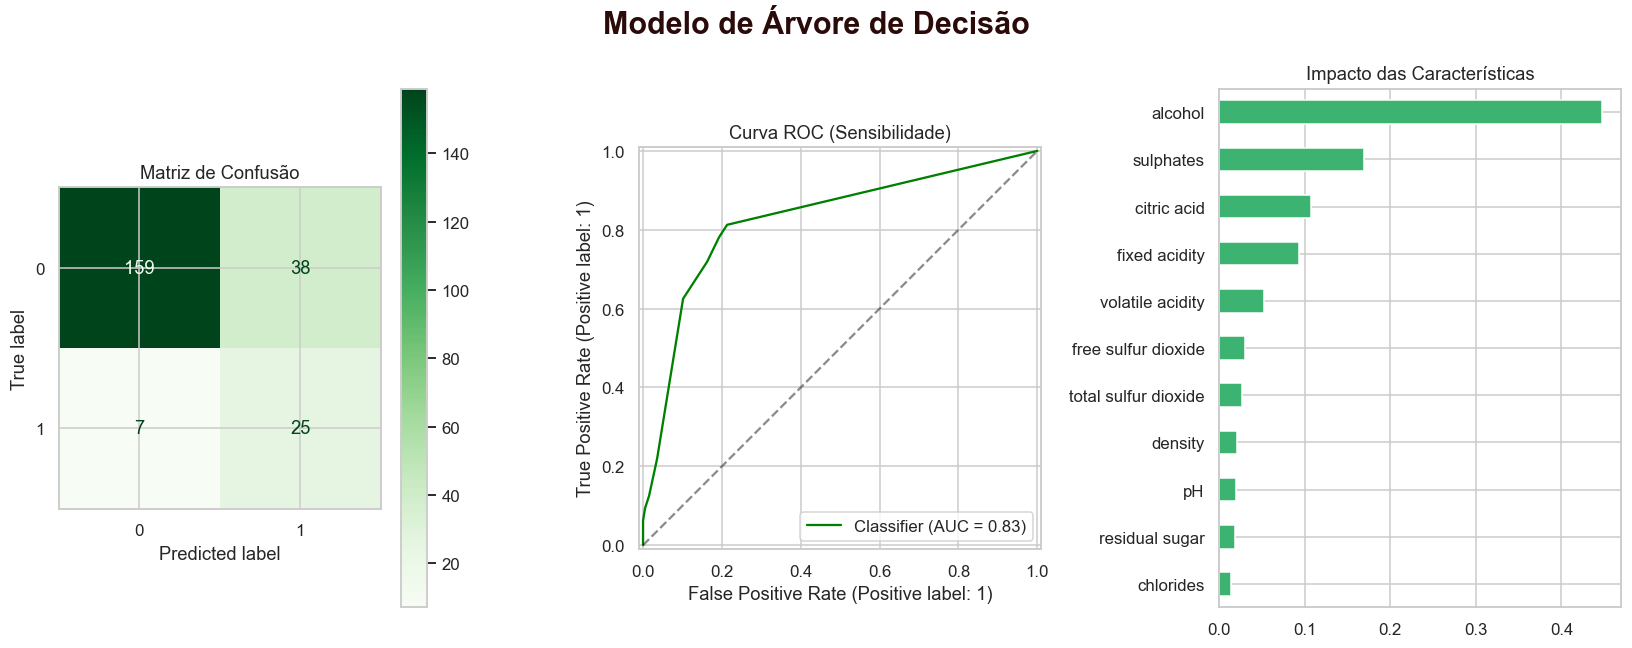

In [43]:
# Configurando o tema visual e o tamanho do painel
sns.set_theme(style="whitegrid") # Configura o estilo visual dos gráficos
plt.rcParams['figure.figsize'] = (15, 6) # Define o tamanho padrão dos gráficos para 15 polegadas de largura e 6 polegadas de altura

# Criando o esqueleto com 3 sub-gráficos lado a lado
fig, (ax1, ax2, ax3) = plt.subplots(1, 3) # Cria uma figura com 3 subplots lado a lado

# Adicionando título principal do modelo
plt.suptitle("Modelo de Árvore de Decisão", fontsize=20, weight='bold', color='#2b0a0a') # Adiciona título principal do modelo com fonte maior, negrito e cor personalizada

# Plotando a Matriz de Confusão no primeiro eixo
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax1, cmap='Greens') # Plota a matriz de confusão usando as previsões do modelo e o conjunto de teste
ax1.set_title("Matriz de Confusão") # Titulo do gráfico da matriz de confusão

# Plotando a Curva ROC no segundo eixo
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax2, color='green') # Plota a curva ROC usando as probabilidades previstas pelo modelo e o conjunto de teste
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax2.set_title("Curva ROC (Sensibilidade)") # Titulo do gráfico da curva ROC

# Extraindo e plotando os coeficientes (impacto) no terceiro eixo
coefs = dt_pipeline.named_steps['model'].feature_importances_ # Acessa os coeficientes do modelo de árvore de decisão treinado, que indicam a importância de cada variável preditora na decisão do modelo
features = X_train.columns                        # Acessa os nomes das colunas do conjunto de treino, que correspondem às variáveis preditoras usadas no modelo
importancia = pd.Series(coefs, index=features).sort_values() # Cria uma série pandas com os coeficientes do modelo, indexada pelos nomes das variáveis preditoras ordenadas
importancia.plot(kind='barh', ax=ax3, color='mediumseagreen') # Plota um gráfico de barras horizontal mostrando a importância de cada característica na decisão do modelo
ax3.set_title("Impacto das Características") # Titulo do gráfico do impacto das características

# Ajustando o espaçamento entre os gráficos
plt.tight_layout()

# Salvando o gráfico automaticamente na pasta de resultados
plt.savefig(results_dir / 'arvore_decisao_outputs.png', dpi=300, bbox_inches='tight')

# Plotando o gráfico
plt.show()

### Análise de Desempenho: Árvore de Decisão

A introdução do modelo não-linear de Árvore de Decisão trouxe uma evolução nítida na capacidade de classificação dos vinhos de nossa adega (Classe 1), superando o modelo de baseline (Regressão Logística) em quase todos os indicadores de interesse.

---

### Os Avanços em relação à Regressão Logística
* **A explosão do recall (78,12% vs. 68,75%):** Foi o grande trunfo deste modelo. A árvore funcionou como uma excelente "pescadora" de vinhos premium, capturando **25 das 32 garrafas de alta qualidade** disponíveis no teste e deixando apenas 7 passarem batidas.
* **Evolução na precisão (39,68% vs. 37,93%):** Embora o número absoluto de alarmes falsos tenha subido ligeiramente (de 36 para 38), o aumento expressivo nos acertos reais (de 22 para 25) compensou a proporção, resultando em uma assertividade superior.
* **Melhor equilíbrio geral (F1-Score: 0,5263 vs. 0,4889):** O salto no F1-Score consolida a Árvore de Decisão como um classificador mais robusto e balanceado para o nosso problema do que a abordagem linear anterior.

### O Gargalo é Persistente
* **O risco dos falsos positivos:** Apesar da melhora percentual na precisão, o índice ainda reside abaixo dos 40%. O modelo entregou **38 vinhos comuns** com o selo de "Alta Qualidade", ainda representando um risco considerável.

---

### Conclusão e próximos passos
> A Árvore de Decisão supera o baseline neste conjunto de teste, indicando que regras baseadas em cortes e ramificações representam melhor as relações não lineares dos dados. Contudo, ainda produziu 38 falsos positivos. O próximo passo é avaliar o **Módulo 3 — Random Forest**, que combina múltiplas árvores para buscar maior estabilidade e precisão.

## Modelo: Random Forest (Floresta Aleatória)

In [44]:
# Montando a esteira Pipeline e ajustando os hiperparâmetros da floresta aleatória
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Substitui valores ausentes pela mediana da coluna
    ('model', RandomForestClassifier(n_estimators=100, # Número de árvores na floresta
                                     class_weight='balanced', # Ajusta o peso das classes para lidar com desbalanceamento
                                     max_depth=5,  # Limita a profundidade máxima da árvore para evitar overfitting (memorização excessiva dos dados de treino)
                                     random_state=42)) # Semente aleatória para os cálculos se repetirem, garantindo reprodutibilidade dos resultados
])

### Treino

In [45]:
# Treinando o Pipeline da Floresta aleatória com os dados de treino
rf_pipeline.fit(X_train, y_train) # O método fit ajusta/treina o modelo com os dados de treino, aplicando as transformações definidas no pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a fe

### Previsões

In [46]:
# Gerando os palpites finais (0 ou 1) com a Floresta aleatória
y_pred = rf_pipeline.predict(X_test) # Este método trás o resultado final

# Gerando as probabilidades de o vinho ser de alta qualidade (Classe 1)
y_proba = rf_pipeline.predict_proba(X_test)[:, 1] # Este método devolve o nível de certeza do modelo trazendo a segunda coluna (1)

### Avaliações métricas

In [47]:
# Métricas de análises individuais para a árvore de decisão
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")  # Taxa de acertos do modelo
print(f"Precisão: {precision_score(y_test, y_pred):.4f}") # Proporção de previsões corretas entre as amostras classificadas como positivas
print(f"Recall:   {recall_score(y_test, y_pred):.4f}")    # Proporção de amostras positivas corretamente identificadas pelo modelo
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")        # Média entre precisão e recall
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")   # Área sob a curva ROC, quanto mais perto do 1.0, mais o modelo distingui que o vinho é bom do que comum

Acurácia: 0.8603
Precisão: 0.5000
Recall:   0.6875
F1-Score: 0.5789
ROC-AUC: 0.8688


### Matriz de confusão

In [48]:
# Matriz de confusão e o relatório resumido
print("\n=== MATRIZ DE CONFUSÃO ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== RELATÓRIO DE CLASSIFICAÇÃO ===")
print(classification_report(y_test, y_pred))


=== MATRIZ DE CONFUSÃO ===
[[175  22]
 [ 10  22]]

=== RELATÓRIO DE CLASSIFICAÇÃO ===
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       197
           1       0.50      0.69      0.58        32

    accuracy                           0.86       229
   macro avg       0.72      0.79      0.75       229
weighted avg       0.88      0.86      0.87       229



### Plotando os resultados 

/Users/danna.bigois/.pyenv/versions/3.13.13/lib/python3.13/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


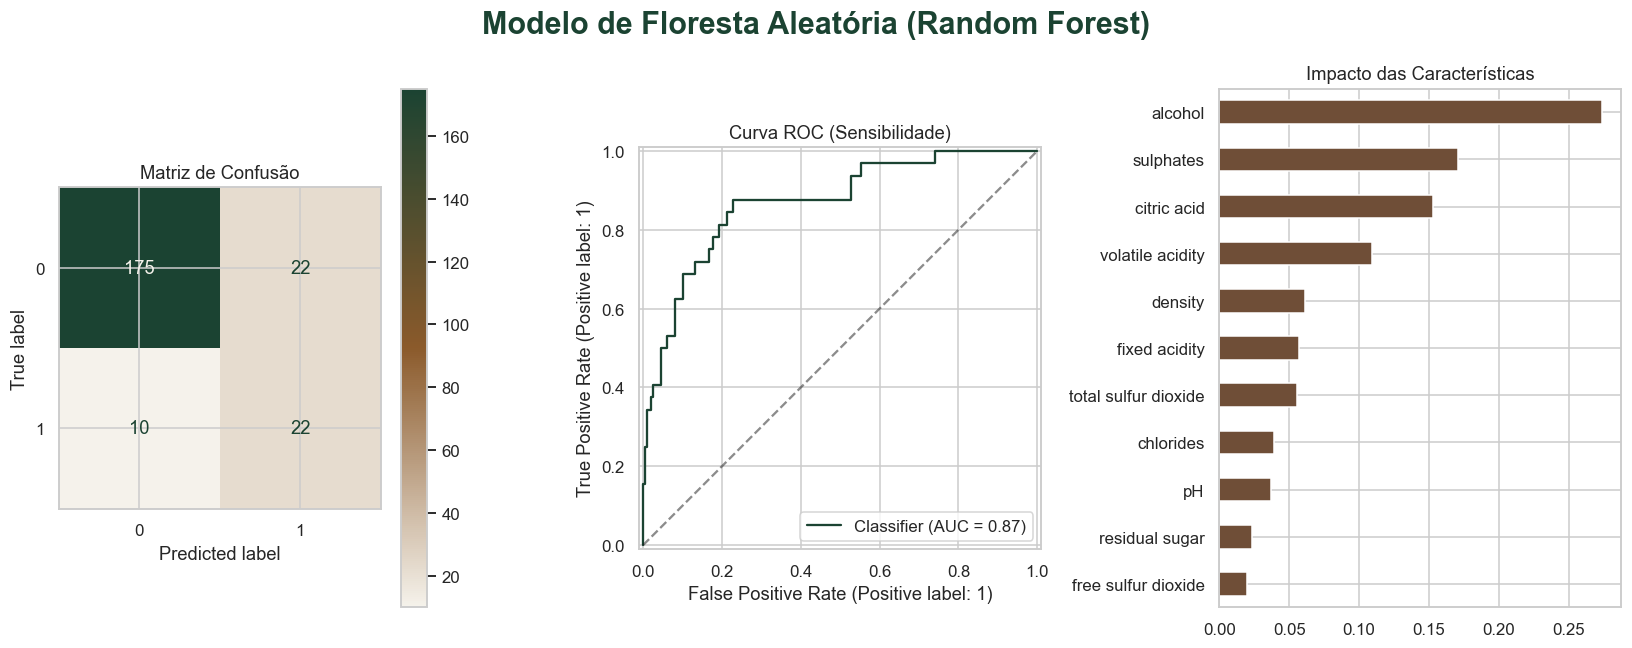

In [49]:
# Configurando o tema visual e o tamanho do painel
sns.set_theme(style="whitegrid") # Configura o estilo visual dos gráficos
plt.rcParams['figure.figsize'] = (15, 6) # Define o tamanho padrão dos gráficos para 15 polegadas de largura e 6 polegadas de altura

# Criando o esqueleto com 3 sub-gráficos lado a lado
fig, (ax1, ax2, ax3) = plt.subplots(1, 3) # Cria uma figura com 3 subplots lado a lado

# Adicionando título principal do modelo
plt.suptitle("Modelo de Floresta Aleatória (Random Forest)", fontsize=20, weight='bold', color='#1b4332') # Ajustado para o verde escuro

# Plotando a Matriz de Confusão no primeiro eixo
cmap_floresta = LinearSegmentedColormap.from_list("floresta", ["#f5f2eb", "#8b5a2b", "#1b4332"]) # Cria um mapa de cores personalizado para a matriz de confusão
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax1, cmap=cmap_floresta) # Plota a matriz de confusão usando as previsões do modelo e o conjunto de teste
ax1.set_title("Matriz de Confusão") # Titulo do gráfico da matriz de confusão

# Plotando a Curva ROC no segundo eixo
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax2, color='#1b4332') # Plota a curva ROC usando as probabilidades previstas pelo modelo e o conjunto de teste
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax2.set_title("Curva ROC (Sensibilidade)") # Titulo do gráfico da curva ROC

# Extraindo e plotando os coeficientes (impacto) no terceiro eixo
coefs = rf_pipeline.named_steps['model'].feature_importances_ # Acessa a importância de cada variável preditora na decisão do modelo
features = X_train.columns                        # Acessa os nomes das colunas do conjunto de treino
importancia = pd.Series(coefs, index=features).sort_values() # Cria uma série pandas com os coeficientes do modelo, indexada pelos nomes das variáveis preditoras ordenadas
importancia.plot(kind='barh', ax=ax3, color='#6f4e37') # Plota um gráfico de barras horizontal mostrando a importância (Marrom)
ax3.set_title("Impacto das Características") # Titulo do gráfico do impacto das características

# Ajustando o espaçamento entre os gráficos
plt.tight_layout()

# Salvando o gráfico automaticamente na pasta de resultados
plt.savefig(results_dir / 'floresta_aleatoria_outputs.png', dpi=300, bbox_inches='tight')

# Plotando o gráfico
plt.show()

### Análise de Desempenho: Random Forest (Floresta Aleatória)

A implementação do modelo de Random Forest marcou o ponto de virada técnico do projeto, consolidando como o classificador mais potente e equilibrado construído até o momento.

---

### Os destaques do campeão
* **O Controle do Gargalo (Precisão de 50,00%):** O voto majoritário das 100 árvores mitigou significativamente os ruídos dos dados químicos, derrubando os alarmes falsos de 38 para **apenas 22**. Conseguimos atingir uma proporção de acerto de 1 para 1 na prateleira premium.
* **Liderança Estatística (ROC-AUC de 0,8688 e Acurácia de 86,03%):** O modelo atingiu o topo histórico do Tech Challenge nesses dois indicadores, validando a robustez da técnica de *Ensemble* para o mapeamento das nuances físicas e químicas das amostras.
* **Sustentação do Recall (68,75%):** Embora tenha recuado em relação à árvore isolada, o modelo manteve a mesma capacidade de captura do baseline e apresentou maior eficiência operacional, com menos falsos positivos para o negócio tratar.

---

### Conclusão do Módulo 3
> A Random Forest assume a liderança isolada do nosso torneio de modelos. Ela mitigou o principal ponto crítico das abordagens anteriores. Para fechar a nossa fase de experimentação conforme as diretrizes do Tech Challenge, avançaremos agora para o **Módulo 4 — SVM (Support Vector Machines)**, testando se fronteiras geométricas complexas conseguem extrair ainda mais valor preditivo da nossa base de dados.

## Modelo SVM (Support Vector Machines) com Kernel (Função de base radial)

In [50]:
# Montando a esteira Pipeline e ajustando os hiperparâmetros do SVM
svm_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Substitui valores ausentes pela mediana da coluna
    ('scaler', StandardScaler()), # Padroniza os dados para média 0 e desvio padrão 1 (campo obrigatório para o SVM)
    ('model', SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42))
])

### Treino

In [51]:
# Treinando o Pipeline do SVM com os dados de treino
svm_pipeline.fit(X_train, y_train) # O método fit ajusta/treina o modelo com os dados de treino, aplicando as transformações definidas no pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

### Previsões

In [52]:
# Gerando os palpites finais (0 ou 1) com a Árvore de Decisão
y_pred = svm_pipeline.predict(X_test) # Este método trás o resultado final

# Gerando as probabilidades de o vinho ser de alta qualidade (Classe 1)
y_proba = svm_pipeline.predict_proba(X_test)[:, 1] # Este método devolve o nível de certeza do modelo trazendo a segunda coluna (1)

### Avaliações métricas

In [53]:
# Métricas de análises individuais para a árvore de decisão
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")  # Taxa de acertos do modelo
print(f"Precisão: {precision_score(y_test, y_pred):.4f}") # Proporção de previsões corretas entre as amostras classificadas como positivas
print(f"Recall:   {recall_score(y_test, y_pred):.4f}")    # Proporção de amostras positivas corretamente identificadas pelo modelo
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")        # Média entre precisão e recall
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")   # Área sob a curva ROC, quanto mais perto do 1.0, mais o modelo distingui que o vinho é bom do que comum

Acurácia: 0.8166
Precisão: 0.4107
Recall:   0.7188
F1-Score: 0.5227
ROC-AUC: 0.8696


### Matriz de confusão

In [54]:
# Matriz de confusão e o relatório resumido
print("\n=== MATRIZ DE CONFUSÃO ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== RELATÓRIO DE CLASSIFICAÇÃO ===")
print(classification_report(y_test, y_pred))


=== MATRIZ DE CONFUSÃO ===
[[164  33]
 [  9  23]]

=== RELATÓRIO DE CLASSIFICAÇÃO ===
              precision    recall  f1-score   support

           0       0.95      0.83      0.89       197
           1       0.41      0.72      0.52        32

    accuracy                           0.82       229
   macro avg       0.68      0.78      0.70       229
weighted avg       0.87      0.82      0.84       229



### Plotando os resultados

/Users/danna.bigois/.pyenv/versions/3.13.13/lib/python3.13/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


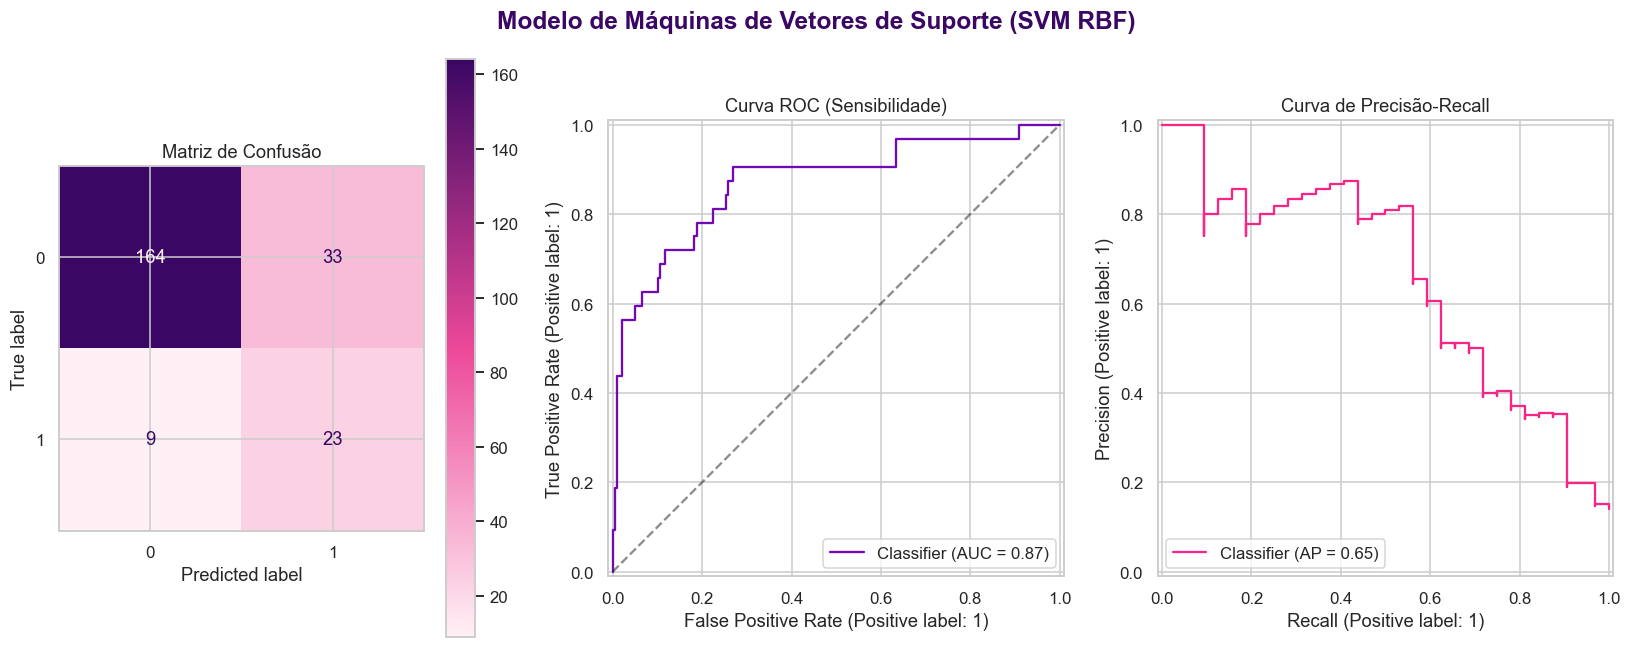

In [55]:
# 1. Configurando o estilo visual e o tamanho do painel
sns.set_theme(style="whitegrid") # Configura o estilo visual dos gráficos
plt.rcParams['figure.figsize'] = (15, 6) # Define o tamanho padrão dos gráficos

# 2. Criando o esqueleto com 3 sub-gráficos lado a lado
fig, (ax1, ax2, ax3) = plt.subplots(1, 3) 

# Título principal em um tom de roxo profundo e elegante
plt.suptitle("Modelo de Máquinas de Vetores de Suporte (SVM RBF)", fontsize=16, weight='bold', color='#3b0764')

# 3. Gráfico 1: Matriz de Confusão (Customizada em degradê de Rosa para Roxo Escuro)
cmap_rosa_roxo = LinearSegmentedColormap.from_list("rosa_roxo", ["#fff0f5", "#ec4899", "#3b0764"])
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax1, cmap=cmap_rosa_roxo)
ax1.set_title("Matriz de Confusão")

# 4. Gráfico 2: Curva ROC (Linha em Roxo Vibrante)
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax2, color='#7209b7')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax2.set_title("Curva ROC (Sensibilidade)")

# 5. Gráfico 3: Curva de Precisão-Recall (Linha em Rosa Choque/Magenta)
PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=ax3, color='#f72585')
ax3.set_title("Curva de Precisão-Recall")

# 6. Ajustando o espaçamento entre os elementos
plt.tight_layout()

# 7. Salvando automaticamente o gráfico temático na sua pasta de resultados
plt.savefig(results_dir / 'svm_rbf_outputs.png', dpi=300, bbox_inches='tight')

# 8. Exibindo o painel na tela
plt.show()

### Análise de Desempenho: SVM (Support Vector Machines)

A aplicação do modelo não-linear de Máquinas de Vetores de Suporte com o kernel RBF trouxe uma perspectiva geométrica interessante para o nosso problema, alcançando o maior poder de separação estatística do projeto, embora com ressalvas práticas para o negócio.

---

### Os pontos fortes e a vitória teórica
* **O Campeão do ROC-AUC (0,8696):** O SVM RBF superou sutilmente todos os outros três competidores neste indicador. Isso prova que a estratégia de projetar as características químicas em uma dimensão superior para encontrar fronteiras curvas é a mais robusta matematicamente para separar os vinhos comuns dos premium.
* **Recall Competitivo (71,88%):** O modelo se mostrou um bom capturador de vinhos de alta qualidade, encontrando **23 das 32 garrafas excelentes** disponíveis no teste e deixando apenas 9 passarem como Falsos Negativos. Ficou acima da Regressão Logística e do Random Forest nesse quesito.

### O Ponto fraco prático
* **A Linha de Corte e os Alarmes Falsos:** Apesar da vitória teórica no ROC-AUC, a linha de corte padrão do SVM não se traduziu no melhor cenário financeiro ou operacional. O modelo gerou **33 alarmes falsos** (vinhos comuns rotulados como premium), o que derrubou sua Precisão para 41,07% e manteve o seu F1-Score (0,5227) abaixo do desempenho obtido pela Random Forest.

---

### Conclusão do Módulo 4
> O SVM com Kernel RBF encerra o nosso torneio de Machine Learning entregando a maior robustez estatística abstrata (área sob a curva). No entanto, para as necessidades práticas da vinícola — que exige um controle rigoroso de alarmes falsos para proteger a reputação da marca na prateleira —, o voto coletivo do **Random Forest (Módulo 3)** provou ser comercialmente superior, consolidando-se como o modelo definitivo a ser escolhido para o projeto.

## 6. Conclusão final: Avaliação comparativa e escolha do melhor modelo
Nesta etapa final, consolidamos o torneio de Machine Learning comparando os quatro modelos treinados para prever a alta qualidade dos vinhos com base em suas propriedades físico-químicas. O objetivo principal do negócio é identificar com segurança as joias da adega (Classe 1 - Premium), minimizando o risco de rotular vinhos comuns como de alta qualidade (falsos positivos) e garantindo que o máximo de vinhos excelentes seja capturado (Recall).

---

#### Quadro Comparativo Geral (O Placar do Torneio)

A tabela abaixo resume o desempenho real obtido por cada algoritmo no conjunto de testes:

| Modelo de Classificação | Acurácia Geral | Precisão (Classe 1) | Recall (Classe 1) | F1-Score (Classe 1) | ROC-AUC Estatístico | Veredito Técnico |
| :--- | :---: | :---: | :---: | :---: | :---: | :--- |
| **1. Regressão Logística** | 79,91% | 37,93% | 68,75% | 0,4889 | 0,8504 | *Baseline linear (Falsos positivos altos)* |
| **2. Árvore de Decisão** | 80,35% | 39,68% | **78,12%** 🎯 | 0,5263 | 0,8258 | *Maior captura (Modelo mais agressivo)* |
| **3. Random Forest** | **86,03%**  | **50,00%**  | 68,75% | **0,5789**  | 0,8688 | **O mais equilibrado (melhor para o negócio)** |
| **4. SVM (Kernel RBF)** | 81,66% | 41,07% | 71,88% | 0,5227 | **0,8696**  | *Maior poder de separação abstrato* |

---

### Análise Crítica dos Modelos e decisão estratégica do Negócio

#### 1. O baseline linear (Regressão Logística)
A abordagem linear serviu como um bom ponto de partida e indicou capacidade preditiva das características físico-químicas (ROC-AUC de 0,8504). No entanto, o modelo foi excessivamente permissivo neste conjunto de teste, gerando **36 falsos positivos** e alcançando precisão de 37,93% para a classe de alta qualidade.

#### 2. A agressividade da Árvore de Decisão
A Árvore de Decisão isolada foi o modelo mais eficiente em "pescar" os vinhos excelentes, atingindo o topo do **Recall com 78,12%** (capturou 25 de 32 vinhos premium). Contudo, essa agressividade veio acompanhada de instabilidade, resultando no maior número absoluto de erros operacionais do torneio (**38 vinhos comuns rotulados erradamente como premium**).

#### 3. A abstração geométrica do SVM RBF
O SVM com Kernel RBF atingiu o maior **ROC-AUC (0,8696)** do projeto, indicando boa capacidade de ordenação e separação das classes. Apesar disso, na linha de corte padrão, alcançou precisão de 41,07% e gerou 33 falsos positivos.

#### 4. O equilíbrio superior do Random Forest
O modelo de **Random Forest (Floresta Aleatória)** apresentou o melhor equilíbrio no conjunto de teste. Ao combinar o voto de 100 árvores treinadas sobre diferentes amostras dos dados e subconjuntos de atributos, reduziu os falsos positivos para 22. Também obteve a maior **Acurácia Geral (86,03%)** e o maior **F1-Score (0,5789)** entre os modelos avaliados.

---

### Modelo recomendado para validação: Random Forest

O **Random Forest** é o candidato recomendado para a próxima etapa de validação. A recomendação baseia-se no desempenho observado no conjunto de teste e nos possíveis impactos operacionais:

1. **Controle de falsos positivos:** No conjunto de teste, a **precisão de 50,00%** significa que metade dos vinhos classificados pelo modelo como alta qualidade pertencia realmente à classe positiva. Esse resultado foi superior ao dos demais modelos, mas ainda demanda validação e melhoria antes de apoiar decisões reais de rotulagem.
2. **Eficiência operacional:** Ao reduzir os alarmes falsos de 38 (Árvore) para 22 (Random Forest), o modelo poupa tempo e custos da equipe de especialistas (sommeliers), que precisará reavaliar muito menos lotes enviados erroneamente para a esteira nobre.
3. **Identificação da classe positiva (Recall de 68,75%):** O Random Forest identificou 22 dos 32 vinhos de alta qualidade no conjunto de teste. Esse resultado mostra potencial de apoio à triagem, sem representar garantia de receita ou desempenho futuro.

---

### Interpretação das características no processo

Com base no modelo recomendado (**Random Forest**), observamos quais propriedades químicas tiveram maior relevância para as previsões. Esses resultados podem orientar novas investigações da equipe de enologia, mas não estabelecem efeitos causais sobre o produto final:

* **O protagonismo do álcool (`alcohol`):** Esta foi a variável mais importante para a decisão do modelo. No processo produtivo, isso indica que uvas colhidas com a maturação ideal (que concentram mais açúcar para ser convertido em álcool na fermentação) são essenciais para gerar vinhos Premium.
* **Influência relevante (`sulphates`, `citric acid` e `volatile acidity`):** Estas três variáveis também apresentaram forte impacto no modelo. Os sulfatos funcionam como conservantes naturais e os ácidos regulam o equilíbrio sensorial do vinho.
* **Associação negativa da acidez volátil (`volatile acidity`):** A análise de correlação mostrou que uma maior acidez volátil está associada negativamente à alta qualidade. Como esse indicador pode estar relacionado à presença de ácido acético e a alterações indesejadas, seu acompanhamento pode ser relevante para a investigação e o controle dos lotes.
* **Associação vs. Causalidade:** É importante registrar explicitamente que essas relações encontradas pelo modelo são **associações estatísticas, e não provas de causalidade**. O modelo aponta quais componentes químicos estão presentes nos vinhos bons, mas a causa real da qualidade depende do manejo correto na adega.


### Próximos passos recomendados (dicas)
* **Otimização de hiperparâmetros:** Realizar um *Grid Search* ou *Random Search* focado especificamente no Random Forest para tunar parâmetros como `max_features`, `min_samples_leaf` e o número de estimadores, visando empurrar a precisão para além dos 50%.
* **Coleta de novos recursos:** Incluir variáveis operacionais e sensoriais externas (como idade das videiras, tempo de maturação em barril de carvalho e região de colheita) para enriquecer os dados físico-químicos atuais e quebrar de vez o gargalo da previsibilidade.